# Validation: CIGALE mock photometry with a mixed prior

This notebook validates the mixed/discrete samplers on a controlled CIGALE problem where the **true model is CIGALE itself**.

The generator and fitter both call `sedinfer.backends.cigale.CIGALEBackend`, which in turn calls `pcigale.warehouse.SedWarehouse`. The purpose is not to prove CIGALE physics; it is to validate that `sedinfer` handles mixed priors, explicit mass normalization, CIGALE discrete module choices, and photometric likelihood evaluation coherently.


## Scientific data flow

1. Define a CIGALE module chain with SFH, BC03 stellar population, attenuation, dust emission, and redshifting.
2. Declare a mixed prior:
   - continuous: `log10_mass`, `tau_main`, `z`, `E_BV_lines`;
   - discrete: `age_main`, `metallicity`, and `qpah`.
3. Generate noiseless photometry by calling the real CIGALE backend at a known truth.
4. Add diagonal Gaussian noise in maggies.
5. Fit the mock object with:
   - a plain all-grid CIGALE baseline on a coarse finite copy of the prior;
   - the two-block mixed Gibbs/SIR sampler;
   - the joint mixed TAMIS sampler.
6. Compare posterior summaries and posterior-predictive photometry to the known truth.

Units and normalization:

- Native CIGALE photometry is returned in mJy and converted by the backend to maggies.
- The CIGALE backend enforces SFH `normalise=True` and declares `PER_SOLAR_MASS`.
- The likelihood is the only place where `10**log10_mass` is applied.
- Fluxes and uncertainties in the dataset are maggies.


In [1]:
from __future__ import annotations

import importlib.util
import json
import os
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path('/Users/gregoire/Documents/Sedfitting/sedinfer-public')
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

CIGALE_SOURCE = Path('/Users/gregoire/Work/cigale-v2022.0')
if CIGALE_SOURCE.exists() and str(CIGALE_SOURCE) not in sys.path:
    sys.path.insert(0, str(CIGALE_SOURCE))

OUTPUT_DIR = REPO_ROOT / 'notebooks' / 'outputs' / 'cigale_mixed_prior_validation'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RUN_VALIDATION = importlib.util.find_spec('pcigale') is not None
RNG_SEED = 20260519

print('Repository:', REPO_ROOT)
print('Output directory:', OUTPUT_DIR)
print('pcigale importable:', RUN_VALIDATION)


Repository: /Users/gregoire/Documents/Sedfitting/sedinfer-public
Output directory: /Users/gregoire/Documents/Sedfitting/sedinfer-public/notebooks/outputs/cigale_mixed_prior_validation
pcigale importable: True


In [2]:
if not RUN_VALIDATION:
    raise ImportError(
        'pcigale is not importable in this Python environment. '
        'Run this validation notebook in the CIGALE environment.'
    )

from inftools import run_grid_sampler, run_mixed_gibbs, run_mixed_tamis
from inftools.core import Posterior
from inftools.mcmc import run_rw_metropolis
from sedinfer import GaussianPhotometricLikelihood, SEDDataset
from sedinfer.backends.cigale import build_cigale_backend_and_parameter_space
from sedinfer.filters import FilterSet
from sedinfer.priors import ChoicePrior, UniformPrior


In [3]:
MODULES = [
    'sfhdelayed',
    'bc03',
    'nebular',
    'dustatt_modified_starburst',
    'dl2014',
    'redshifting',
]

MODULE_PARAMETERS_MIXED = {
    'sfhdelayed': {
        'tau_main': {'range': [500.0, 6000.0]},
        'age_main': {'values': [1000, 3000, 5000, 7000], 'dtype': 'int'},
    },
    'bc03': {
        'imf': 1,
        'metallicity': {'values': [0.004, 0.008, 0.02]},
        'separation_age': 10,
    },
    'nebular': {
        'logU': -2.0,
        # CIGALE v2022 nebular templates are tabulated on discrete gas metallicities;
        # 0.019 is the solar-like value available in the database.
        'zgas': 0.019,
        'ne': 100,
        'f_esc': 0.0,
        'f_dust': 0.0,
        'lines_width': 300.0,
        'emission': True,
    },
    'dustatt_modified_starburst': {
        'E_BV_lines': {'range': [0.0, 0.5]},
        'E_BV_factor': 0.44,
        'uv_bump_wavelength': 217.5,
        'uv_bump_width': 35.0,
        'uv_bump_amplitude': 0.0,
        'powerlaw_slope': 0.0,
        'Ext_law_emission_lines': 1,
        'Rv': 3.1,
        'filters': 'B_B90 & V_B90',
    },
    'dl2014': {
        'qpah': {'values': [0.47, 1.77, 3.90]},
        'umin': 1.0,
        'alpha': 2.0,
        'gamma': 0.02,
    },
    'redshifting': {
        'redshift': {'name': 'z', 'range': [0.05, 1.2]},
    },
}

FILTER_NAMES = ['sdss.up', 'sdss.gp', 'sdss.rp', 'sdss.ip', 'sdss.zp']
filters = FilterSet(FILTER_NAMES)

truth = {
    'log10_mass': 10.4,
    'tau_main': 2200.0,
    'age_main': 5000.0,
    'metallicity': 0.02,
    'E_BV_lines': 0.18,
    'qpah': 1.77,
    'z': 0.42,
}

backend, parameter_space = build_cigale_backend_and_parameter_space(
    MODULES,
    MODULE_PARAMETERS_MIXED,
    additional_priors={'log10_mass': UniformPrior(8.5, 11.8)},
    photometry_mode='cigale',
)

print('Parameter order:', parameter_space.names)
print('Mass normalization:', backend.mass_normalization.name)


Parameter order: ('log10_mass', 'tau_main', 'age_main', 'metallicity', 'E_BV_lines', 'qpah', 'z')
Mass normalization: PER_SOLAR_MASS


In [4]:
rng = np.random.default_rng(RNG_SEED)

theta_true = parameter_space.from_dict(truth)
placeholder = SEDDataset(
    band_names=FILTER_NAMES,
    flux=np.ones(len(FILTER_NAMES)),
    sigma=np.ones(len(FILTER_NAMES)),
    metadata={'filters': filters},
)
truth_like = GaussianPhotometricLikelihood(backend, placeholder, parameter_space, filters=filters)
noiseless_flux = truth_like.simulate(theta_true, noise_fn=lambda flux: np.zeros_like(flux), rng=rng)

relative_error = 0.10
noise_floor = 2e-13
sigma = relative_error * np.abs(noiseless_flux) + noise_floor
observed_flux = noiseless_flux + rng.normal(0.0, sigma)

mock_data = SEDDataset(
    band_names=FILTER_NAMES,
    flux=observed_flux,
    sigma=sigma,
    metadata={'filters': filters, 'truth': truth},
)
likelihood = GaussianPhotometricLikelihood(backend, mock_data, parameter_space, filters=filters)
posterior = Posterior(likelihood.log_prob, dim=parameter_space.ndim, theta_names=parameter_space.names)

phot_table = pd.DataFrame({
    'band': FILTER_NAMES,
    'noiseless_maggies': noiseless_flux,
    'observed_maggies': observed_flux,
    'sigma_maggies': sigma,
    'SNR': observed_flux / sigma,
})

display(phot_table)
print('Truth log posterior:', likelihood.log_prob(theta_true))
assert np.all(np.isfinite(noiseless_flux))
assert np.all(np.isfinite(observed_flux))
assert np.all(sigma > 0)

np.savez(
    OUTPUT_DIR / 'cigale_mixed_prior_mock.npz',
    filter_names=np.asarray(FILTER_NAMES),
    noiseless_flux_maggies=noiseless_flux,
    observed_flux_maggies=observed_flux,
    sigma_maggies=sigma,
    true_theta=theta_true,
    true_theta_names=np.asarray(parameter_space.names),
)
(OUTPUT_DIR / 'truth.json').write_text(json.dumps(truth, indent=2))


/Users/gregoire/Work/cigale-v2022.0/pcigale/data/__init__.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


,band,noiseless_maggies,observed_maggies,sigma_maggies,SNR
0,sdss.up,1.783439e-09,1.728491e-09,1.785439e-10,9.681038
1,sdss.gp,2.370797e-09,2.401023e-09,2.372797e-10,10.118958
2,sdss.rp,5.209087e-09,5.128610e-09,5.211087e-10,9.841728
3,sdss.ip,6.955339e-09,7.125653e-09,6.957339e-10,10.241923
4,sdss.zp,8.457422e-09,8.157643e-09,8.459422e-10,9.643263


Truth log posterior: 90.36825248152508


142

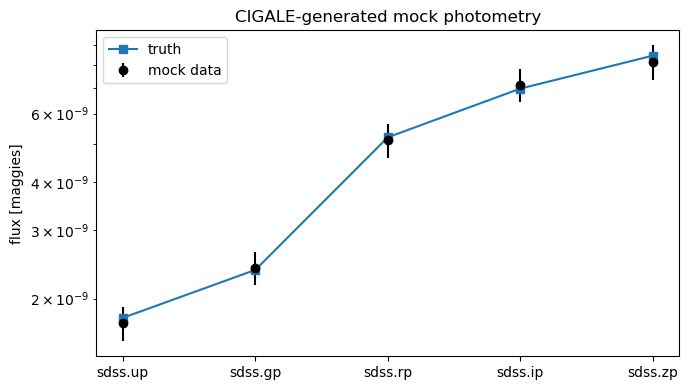

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(FILTER_NAMES))
ax.errorbar(x, observed_flux, yerr=sigma, fmt='o', color='black', label='mock data')
ax.plot(x, noiseless_flux, 's-', color='tab:blue', label='truth')
ax.set_xticks(x, FILTER_NAMES)
ax.set_ylabel('flux [maggies]')
ax.set_yscale('log')
ax.set_title('CIGALE-generated mock photometry')
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'mock_photometry.png', dpi=180)
plt.show()


## Coarse all-grid CIGALE baseline

This is the exact-grid mode. It is useful as a provenance check and a comparison to classic CIGALE behavior. The grid intentionally includes the true values, but it is coarser than the continuous mixed prior.


In [6]:
MODULE_PARAMETERS_GRID = {
    'sfhdelayed': {
        'tau_main': {'values': [1200.0, 2200.0, 4200.0]},
        'age_main': {'values': [1000, 3000, 5000, 7000], 'dtype': 'int'},
    },
    'bc03': {
        'imf': 1,
        'metallicity': {'values': [0.004, 0.008, 0.02]},
        'separation_age': 10,
    },
    'nebular': MODULE_PARAMETERS_MIXED['nebular'],
    'dustatt_modified_starburst': {
        **{k: v for k, v in MODULE_PARAMETERS_MIXED['dustatt_modified_starburst'].items() if k != 'E_BV_lines'},
        'E_BV_lines': {'values': [0.05, 0.18, 0.35]},
    },
    'dl2014': MODULE_PARAMETERS_MIXED['dl2014'],
    'redshifting': {
        'redshift': {'name': 'z', 'values': [0.30, 0.42, 0.65]},
    },
}

grid_backend, grid_space = build_cigale_backend_and_parameter_space(
    MODULES,
    MODULE_PARAMETERS_GRID,
    additional_priors={'log10_mass': ChoicePrior([10.0, 10.4, 10.8])},
    photometry_mode='cigale',
)
grid_like = GaussianPhotometricLikelihood(grid_backend, mock_data, grid_space, filters=filters)
grid_posterior = Posterior(grid_like.log_prob, dim=grid_space.ndim, theta_names=grid_space.names)

t0 = time.perf_counter()
grid_result = run_grid_sampler(grid_posterior, grid_space, max_size=20_000)
print(f'Grid runtime: {time.perf_counter() - t0:.2f} s for {len(grid_result.samples)} models')

grid_df = pd.DataFrame(grid_result.samples, columns=grid_space.names)
grid_df['logp'] = grid_result.logp
grid_df['weight'] = grid_result.meta['weights_norm']
display(grid_df.sort_values('weight', ascending=False).head(10))


Grid runtime: 1.73 s for 2916 models


,log10_mass,tau_main,age_main,metallicity,E_BV_lines,qpah,z,logp,weight
1528,10.4,2200.0,5000.0,0.020,0.18,3.90,0.42,95.226844,0.073864
1522,10.4,2200.0,5000.0,0.020,0.18,0.47,0.42,95.226844,0.073864
1525,10.4,2200.0,5000.0,0.020,0.18,1.77,0.42,95.226844,0.073864
1861,10.4,4200.0,5000.0,0.020,0.35,3.90,0.42,94.776378,0.047076
1855,10.4,4200.0,5000.0,0.020,0.35,0.47,0.42,94.776378,0.047076
1858,10.4,4200.0,5000.0,0.020,0.35,1.77,0.42,94.776378,0.047076
1906,10.4,4200.0,7000.0,0.008,0.18,3.90,0.42,94.760588,0.046338
1903,10.4,4200.0,7000.0,0.008,0.18,1.77,0.42,94.760588,0.046338
1900,10.4,4200.0,7000.0,0.008,0.18,0.47,0.42,94.760588,0.046338
421,10.0,2200.0,3000.0,0.004,0.18,3.90,0.42,94.120846,0.024440


## Mixed Gibbs and mixed TAMIS fits

These are the true mixed-RV fits. The discrete CIGALE choices remain categorical. The continuous variables are sampled as continuous quantities.


In [7]:
x0 = parameter_space.from_dict({
    'log10_mass': 10.2,
    'tau_main': 2600.0,
    'age_main': 3000.0,
    'metallicity': 0.008,
    'E_BV_lines': 0.12,
    'qpah': 1.77,
    'z': 0.35,
})

continuous_cov = np.diag([0.04**2, 350.0**2, 0.04**2, 0.04**2])

t0 = time.perf_counter()
gibbs_result = run_mixed_gibbs(
    posterior,
    parameter_space,
    x0=x0,
    # Outer Gibbs iterations. Each iteration samples the discrete CIGALE grid
    # conditional on the current continuous parameters, then advances the
    # continuous block with the inner RW-Metropolis transition below.
    nsteps=400,
    continuous_sampler=run_rw_metropolis,
    continuous_sampler_kwargs={
        'nsteps': 35,
        'burnin': 12,
        'thin': 2,
        'proposal_cov': continuous_cov,
    },
    discrete_candidates=None,
    discrete_probability_floor='survival',
    discrete_floor_failure_probability=1e-5,
    rng=np.random.default_rng(RNG_SEED + 1),
)
gibbs_runtime = time.perf_counter() - t0

# Mixed TAMIS is the closest descendant of the old MC-CIGALE experiment.
t0 = time.perf_counter()
tamis_result = run_mixed_tamis(
    posterior,
    parameter_space,
    x0=x0,
    n_comp=3,
    T_max=50,
    n_per_iter=120,
    init_span=0.6,
    var0=np.array([0.12**2, 900.0**2, 0.12**2, 0.12**2]),
    alpha=60,
    discrete_probability_floor='survival',
    discrete_floor_failure_probability=1e-5,
    seed=RNG_SEED + 2,
)
tamis_runtime = time.perf_counter() - t0

print(f'Gibbs runtime: {gibbs_runtime:.2f} s, samples={len(gibbs_result.samples)}')
print(f'Mixed TAMIS runtime: {tamis_runtime:.2f} s, samples={len(tamis_result.samples)}')
print('Gibbs MAP:', dict(zip(parameter_space.names, gibbs_result.map_estimate)))
print('Mixed TAMIS MAP:', dict(zip(parameter_space.names, tamis_result.map_estimate)))
print('Mixed TAMIS betas:', tamis_result.meta['betas'])


Gibbs runtime: 167.08 s, samples=400
Mixed TAMIS runtime: 71.42 s, samples=6000
Gibbs MAP: {'log10_mass': 10.366334957552178, 'tau_main': 4411.840272306614, 'age_main': 7000.0, 'metallicity': 0.004, 'E_BV_lines': 0.13932928163391806, 'qpah': 0.47, 'z': 0.44961858830291546}
Mixed TAMIS MAP: {'log10_mass': 10.398693364609718, 'tau_main': 2738.3802239011334, 'age_main': 7000.0, 'metallicity': 0.008, 'E_BV_lines': 0.06463507821396725, 'qpah': 0.47, 'z': 0.42262432082545753}
Mixed TAMIS betas: [8.88178420e-16 6.95203784e-05 3.72719618e-03 1.64037144e-02
 3.48167331e-02 1.31317146e-01 2.72650595e-01 2.71706171e-01
 3.37182559e-01 3.59336890e-01 4.30841773e-01 4.10063983e-01
 4.73276784e-01 3.59183197e-01 3.58624690e-01 5.27297776e-01
 6.16869707e-01 4.12539154e-01 4.98342490e-01 4.28731029e-01
 3.45225917e-01 2.80204680e-01 3.32944354e-01 3.75906323e-01
 4.38004127e-01 3.77176870e-01 3.63495731e-01 4.63096299e-01
 3.90887764e-01 4.67015312e-01 6.36910708e-01 3.71275521e-01
 3.53469190e-01 3.

In [8]:
def weighted_quantile(values, weights, qs):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    order = np.argsort(values)
    values = values[order]
    weights = weights[order] / np.sum(weights)
    cdf = np.cumsum(weights)
    return np.interp(qs, cdf, values)

def summarize_result(name, result, weights):
    rows = []
    for j, pname in enumerate(parameter_space.names):
        q16, q50, q84 = weighted_quantile(result.samples[:, j], weights, [0.16, 0.50, 0.84])
        rows.append({
            'sampler': name,
            'parameter': pname,
            'truth': truth[pname],
            'q16': q16,
            'median': q50,
            'q84': q84,
        })
    return rows

summary = pd.DataFrame(
    summarize_result('grid', grid_result, grid_result.meta['weights_norm'])
    + summarize_result('gibbs', gibbs_result, np.ones(len(gibbs_result.samples)) / len(gibbs_result.samples))
    + summarize_result('mixed_tamis', tamis_result, tamis_result.meta['weights_norm'])
)
display(summary)
summary.to_csv(OUTPUT_DIR / 'posterior_summary.csv', index=False)


,sampler,parameter,truth,q16,median,q84
0,grid,log10_mass,10.40,10.000000,10.400000,10.400000
1,grid,tau_main,2200.00,2200.000000,2200.000000,4200.000000
2,grid,age_main,5000.00,3000.000000,5000.000000,7000.000000
3,grid,metallicity,0.02,0.004000,0.020000,0.020000
4,grid,E_BV_lines,0.18,0.106855,0.180000,0.350000
5,grid,qpah,1.77,0.470000,1.770000,3.900000
6,grid,z,0.42,0.420000,0.420000,0.420000
7,gibbs,log10_mass,10.40,9.963424,10.319288,10.554827
8,gibbs,tau_main,2200.00,2815.646581,4115.111930,5345.138411
9,gibbs,age_main,5000.00,1000.000000,5000.000000,7000.000000


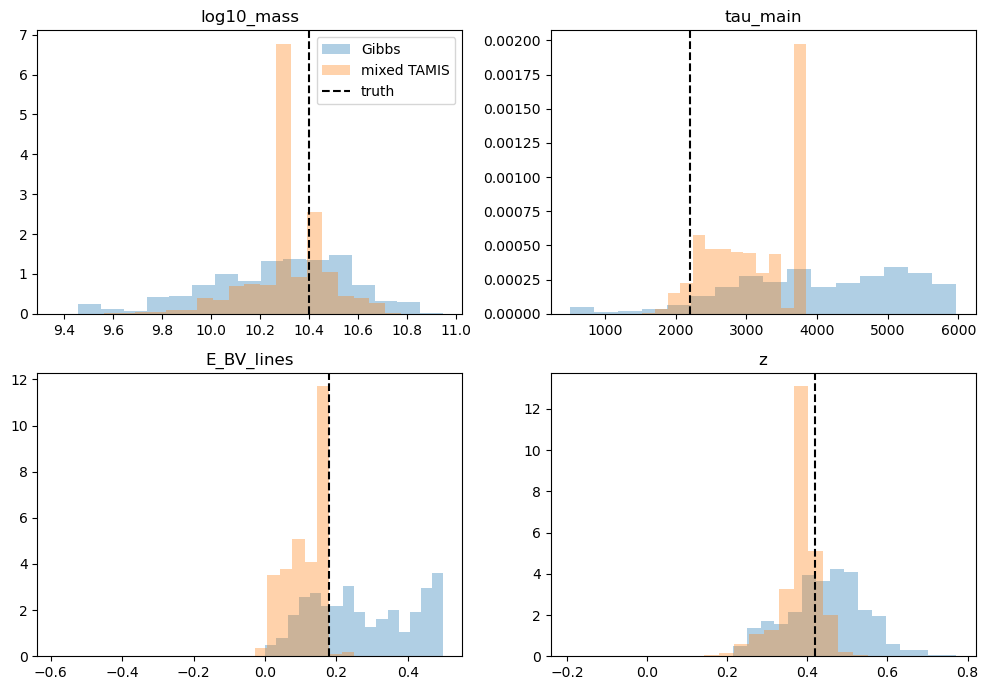

In [9]:
plot_params = ['log10_mass', 'tau_main', 'E_BV_lines', 'z']
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for ax, pname in zip(axes.ravel(), plot_params):
    j = parameter_space.names.index(pname)
    ax.hist(gibbs_result.samples[:, j], bins=16, alpha=0.35, density=True, label='Gibbs')
    ax.hist(tamis_result.samples[:, j], bins=24, alpha=0.35, density=True, weights=tamis_result.meta['weights_norm'], label='mixed TAMIS')
    ax.axvline(truth[pname], color='black', linestyle='--', label='truth' if pname == plot_params[0] else None)
    ax.set_title(pname)
axes.ravel()[0].legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'continuous_parameter_posteriors.png', dpi=180)
plt.show()


In [10]:
def weighted_category_table(result, weights, parameter):
    j = parameter_space.names.index(parameter)
    values = np.unique(result.samples[:, j])
    rows = []
    for value in values:
        rows.append({'value': value, 'weight': float(np.sum(weights[np.isclose(result.samples[:, j], value)]))})
    return pd.DataFrame(rows).sort_values('value')

for parameter in ['age_main', 'metallicity', 'qpah']:
    print(parameter)
    display(pd.concat({
        'grid': weighted_category_table(grid_result, grid_result.meta['weights_norm'], parameter),
        'gibbs': weighted_category_table(gibbs_result, np.ones(len(gibbs_result.samples)) / len(gibbs_result.samples), parameter),
        'mixed_tamis': weighted_category_table(tamis_result, tamis_result.meta['weights_norm'], parameter),
    }))


age_main


value        weight
grid        0  1000.0  6.108257e-11
            1  3000.0  2.370059e-01
            2  5000.0  4.773422e-01
            3  7000.0  2.856519e-01
gibbs       0  1000.0  1.675000e-01
            1  3000.0  1.650000e-01
            2  5000.0  2.300000e-01
            3  7000.0  4.375000e-01
mixed_tamis 0  1000.0  0.000000e+00
            1  3000.0  0.000000e+00
            2  5000.0  5.034190e-03
            3  7000.0  9.949658e-01

metallicity


value    weight
grid        0  0.004  0.230354
            1  0.008  0.263269
            2  0.020  0.506377
gibbs       0  0.004  0.395000
            1  0.008  0.370000
            2  0.020  0.235000
mixed_tamis 0  0.004  0.383089
            1  0.008  0.333053
            2  0.020  0.283857

qpah


value    weight
grid        0   0.47  0.333333
            1   1.77  0.333333
            2   3.90  0.333333
gibbs       0   0.47  0.330000
            1   1.77  0.352500
            2   3.90  0.317500
mixed_tamis 0   0.47  0.223300
            1   1.77  0.572274
            2   3.90  0.204426

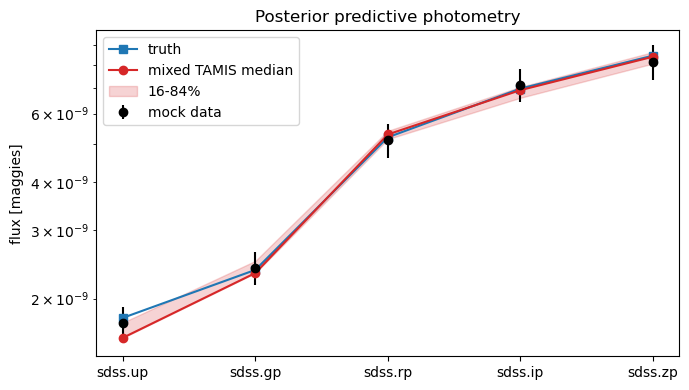

In [11]:
def model_flux_for_theta(theta):
    params = parameter_space.to_dict(theta)
    backend_params = {k: v for k, v in params.items() if k != 'log10_mass'}
    per_mass = backend.predict_photometry(backend_params, filters).flux
    return (10.0 ** params['log10_mass']) * per_mass

def posterior_predictive(result, weights, n=80, seed=99):
    rng = np.random.default_rng(seed)
    weights = np.asarray(weights, dtype=float)
    weights = weights / np.sum(weights)
    idx = rng.choice(np.arange(len(result.samples)), size=min(n, len(result.samples)), replace=True, p=weights)
    return np.asarray([model_flux_for_theta(result.samples[i]) for i in idx])

pp_tamis = posterior_predictive(tamis_result, tamis_result.meta['weights_norm'], n=80)
pp_median = np.median(pp_tamis, axis=0)
pp_lo, pp_hi = np.percentile(pp_tamis, [16, 84], axis=0)

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(FILTER_NAMES))
ax.errorbar(x, observed_flux, yerr=sigma, fmt='o', color='black', label='mock data')
ax.plot(x, noiseless_flux, 's-', color='tab:blue', label='truth')
ax.plot(x, pp_median, 'o-', color='tab:red', label='mixed TAMIS median')
ax.fill_between(x, pp_lo, pp_hi, color='tab:red', alpha=0.2, label='16-84%')
ax.set_xticks(x, FILTER_NAMES)
ax.set_yscale('log')
ax.set_ylabel('flux [maggies]')
ax.set_title('Posterior predictive photometry')
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'posterior_predictive_photometry.png', dpi=180)
plt.show()


In [12]:
np.savez(
    OUTPUT_DIR / 'mixed_sampler_results.npz',
    parameter_names=np.asarray(parameter_space.names),
    truth=np.asarray([truth[name] for name in parameter_space.names]),
    grid_samples=grid_result.samples,
    grid_logp=grid_result.logp,
    grid_weights=grid_result.meta['weights_norm'],
    gibbs_samples=gibbs_result.samples,
    gibbs_logp=gibbs_result.logp,
    tamis_samples=tamis_result.samples,
    tamis_logp=tamis_result.logp,
    tamis_weights=tamis_result.meta['weights_norm'],
    tamis_betas=tamis_result.meta['betas'],
    noiseless_flux_maggies=noiseless_flux,
    observed_flux_maggies=observed_flux,
    sigma_maggies=sigma,
)
print('Saved outputs to', OUTPUT_DIR)


Saved outputs to /Users/gregoire/Documents/Sedfitting/sedinfer-public/notebooks/outputs/cigale_mixed_prior_validation
